## Assignment 1

Linear regression by using Deep Neural network: Implement Boston housing price predictionproblem by Linear regression using Deep Neural network. Use Boston House price prediction dataset.

In [67]:
!pip install pandas
!pip install scikit-learn
!pip install tensorflow
!pip install seaborn

In [68]:
import pandas as pd

In [69]:
df = pd.read_csv("HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [70]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [71]:
df.isna().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [72]:
for column in df.columns:
    mean = df[column].mean()
    df[column] = df[column].fillna(value=mean)

df.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

<Axes: ylabel='MEDV'>

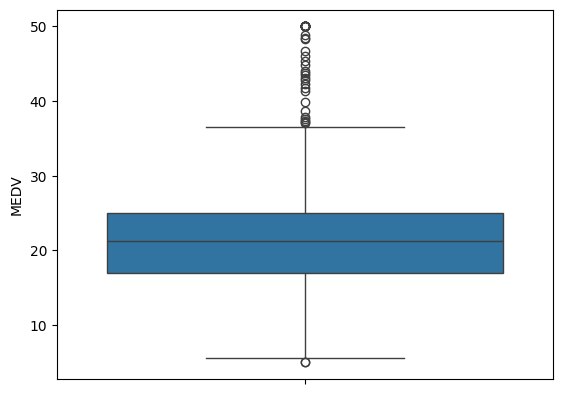

In [73]:
# Use box plot to see any outliers
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(y=df["MEDV"])

Removed 40 rows from df


<Axes: ylabel='MEDV'>

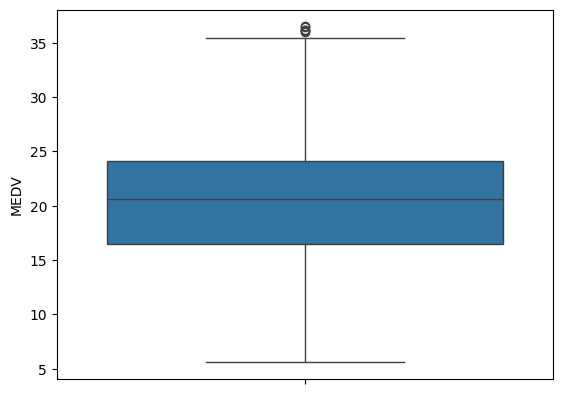

In [74]:
def remove_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower_fence = q1 - 1.5 * IQR
    upper_fence = q3 + 1.5 * IQR
    filtered_df = df[(df[col] >= lower_fence) & (df[col] <= upper_fence)]
    outliers_removed = len(df) - len(filtered_df)
    print(f"Removed {outliers_removed} rows from df")
    return filtered_df, outliers_removed

df, num = remove_outliers(df, 'MEDV')

sns.boxplot(y=df['MEDV'])

In [75]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000
mean,3.586269,10.367628,11.325128,0.060942,0.556826,6.179633,68.731362,3.833586,9.669528,413.105150,18.617382,354.197790,13.303965,20.719099
std,8.183586,21.722403,6.619018,0.233566,0.117400,0.576325,27.336403,2.124901,8.792361,168.544572,2.063273,94.679607,6.814424,6.451416
min,0.006320,0.000000,0.740000,0.000000,0.385000,3.561000,2.900000,1.137000,1.000000,187.000000,12.600000,0.320000,1.980000,5.600000
25%,0.085120,0.000000,5.860000,0.000000,0.453000,5.876250,46.400000,2.104425,4.000000,284.000000,17.400000,374.590000,7.927500,16.500000
50%,0.274475,0.000000,9.955000,0.000000,0.538000,6.163500,74.650000,3.272100,5.000000,335.000000,19.100000,391.955000,12.670000,20.600000
75%,3.611874,11.211934,18.100000,0.000000,0.624000,6.506250,93.750000,5.241300,24.000000,666.000000,20.200000,396.397500,17.107500,24.075000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,36.500000


In [76]:
# Separate the target feature
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [77]:
# Do the train test split
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [78]:
# Scale the inputs
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
X_train = scalar.fit_transform(X_train_raw)
X_test  = scalar.fit_transform(X_test_raw)


In [79]:
# Create the model

# Step 1: Create the layers
from tensorflow.keras.layers import Dense

# - 128 neurons
# - Input shape is (13,) because Boston Housing dataset has 13 features
# - 'relu' activation adds non-linearity
layer1 = Dense(128, input_shape=(13,), activation='relu', name='dense_1')

# - 64 neurons
# - Again uses 'relu' activation for non-linearity
layer2 = Dense(64, activation='relu', name='dense_2')

# Output layer:
# - 1 neuron since we're predicting a single continuous value (house price)
# - 'linear' activation means no transformation (suitable for regression)
layer3 = Dense(1, activation='linear', name='dense_output')

c:\Users\LENOVO\Desktop\BE-Lab-Assignments\LP-V\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
# Add the layers to the model
from tensorflow.keras.models import Sequential
model = Sequential()

model.add(layer1)
model.add(layer2)
model.add(layer3)

# Compile the model
# - 'adam' optimizer adjusts weights efficiently
# - 'mse' (mean squared error) is the loss function for regression
# - 'mae' (mean absolute error) as a metric for performance monitoring
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Print a summary of the model architecture
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
# Train the model

model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.05,
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 461.4362 - mae: 20.4248 - val_loss: 342.4997 - val_mae: 17.4187
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 396.2903 - mae: 18.7706 - val_loss: 283.1972 - val_mae: 15.6692
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 321.8361 - mae: 16.7545 - val_loss: 214.7432 - val_mae: 13.3866
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 231.9407 - mae: 14.0522 - val_loss: 139.5042 - val_mae: 10.3273
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 143.4735 - mae: 10.7044 - val_loss: 72.5645 - val_mae: 7.0725
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 70.9537 - mae: 7.1909 - val_loss: 36.1686 - val_mae: 5.3441
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 41.2206 - mae: 5.2530 - val_loss: 25.6349 - val_mae: 4.1016
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 32.9176 - mae: 4.5262 - val_loss: 21.8128 - val_mae: 3.4129
Epoch 9/100
10/10 ━━━━━━━━━━━

In [82]:
# Evaluate the model on the scaled test data
# Returns loss (MSE) and metrics (MAE, as specified during model compilation)
mse_nn, mae_nn = model.evaluate(X_test, y_test)

# Print the evaluation results
print('Mean squared error on test data: ', mse_nn)  # Measures average of squared prediction errors
print('Mean absolute error on test data: ', mae_nn)  # Measures average of absolute prediction errors

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.9759 - mae: 2.3014 
Mean squared error on test data:  8.975875854492188
Mean absolute error on test data:  2.3014066219329834
